<a href="https://colab.research.google.com/github/Plumz17/PP_FinalProject2/blob/main/PP_FinalProject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pattern Recognition Project - Banana Variety and Ripeness Classification using Traditional ML Feature Extraction Methods
Arranged by:
*   Anders Emmanuel Tan (24/541351/PA/22964)
*   Danar Fathurahman (24/538200/PA/22828)

Description: Pada projek ini, kami akan menyusun pipeline lengkap menggunakan teknik-teknik ekstraksi fitur tradisional untuk mengklasifikasi jenis dan tingkat kematangan pisang di Indonesia. Dataset yang digunakan tersedia di tautan berikut: https://data.mendeley.com/datasets/h6n5srjjyw/1

## 0. Image Acquisition (Loading the Dataset)
Description:

In [98]:
#Reset Runtime file
!rm -rf *
!pip install mahotas

In [99]:
# Import Important Libraries
import requests, os, zipfile, io, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tqdm import tqdm
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog
from mahotas.features import zernike_moments

In [100]:
# Initialize Important Variables
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

MODELS_DIR  = "/content/models"
RESULTS_DIR = "/content/results"
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [101]:
# Import Dataset
URL = "https://data.mendeley.com/public-api/zip/h6n5srjjyw/download/1"
os.makedirs("/content/banana", exist_ok=True)

r = requests.get(URL, stream=True, headers={"User-Agent": "Mozilla/5.0"})
total = int(r.headers.get("content-length", 0))

with open("/content/banana.zip", "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
  for chunk in r.iter_content(chunk_size=1024*1024):
    f.write(chunk)
    bar.update(len(chunk))

print("\n")
print("Download Complete!")

100%|██████████| 715M/715M [00:20<00:00, 34.6MB/s]



Download Complete!


In [102]:
# Extract outer zip
BASE_DIR = "/content/banana/BananaID An image dataset of banana varieties and/"
IMG_DIR  = "/content/banana_images"
with zipfile.ZipFile("/content/banana.zip") as z:
    z.extractall("/content/banana/")

# Extract all four inner zips
inner_zips = {
  "Banana Variety Dataset.zip":"variety_original",
  "Banana Ripeness Dataset.zip":"ripeness_original",
  "Augmented Banana Variety Dataset.zip":"variety_augmented",
  "Augmented Banana Ripeness Dataset.zip":"ripeness_augmented",
}

for zip_name, out_folder in inner_zips.items():
  zip_path = os.path.join(BASE_DIR, zip_name)
  out_path = os.path.join(IMG_DIR, out_folder)
  print(f"Extracting {zip_name}...")
  with zipfile.ZipFile(zip_path) as z:
    z.extractall(out_path)

print("Extraction complete!")

Extracting Banana Variety Dataset.zip...
Extracting Banana Ripeness Dataset.zip...
Extracting Augmented Banana Variety Dataset.zip...
Extracting Augmented Banana Ripeness Dataset.zip...
Extraction complete!


## 1. Preprocessing


In [103]:
#Variety Preprocessing
VARIETY_DIR = os.path.join(IMG_DIR, "variety_original/Banana Classification Dataset")

#Intialize array for images and labels
variety_images, variety_labels = [], []
#Name Banana's Variety class as their folder name
variety_class_names = sorted(os.listdir(VARIETY_DIR))
#Maps each class name with a number
variety_class_to_idx = {cls: idx for idx, cls in enumerate(variety_class_names)}

for class_name in tqdm(variety_class_names, desc="Preprocessing Banana Variety..."):
  #Get Filepath to specific variety class path
  class_path = os.path.join(VARIETY_DIR, class_name)
  for img_file in os.listdir(class_path):
    #Obtain image
    img = cv2.imread(os.path.join(class_path, img_file))
    if img is None:
      continue
    #Convert image to RGB for convinience sake
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Add image to image array
    variety_images.append(img)
    #Add label to label array
    variety_labels.append(variety_class_to_idx[class_name])

#Normalize and convert into a numpy array
variety_images = np.array(variety_images, dtype=np.uint8)
variety_labels = np.array(variety_labels)

print(f"Images : {variety_images.shape}")
print(f"Labels : {variety_labels.shape}")
print(f"Classes: {variety_class_names}")

Preprocessing Banana Variety...: 100%|██████████| 5/5 [00:03<00:00,  1.42it/s]


Images : (1960, 256, 384, 3)
Labels : (1960,)
Classes: ['Ambon', 'Cavendish', 'Mas', 'Raja', 'Saba']


In [104]:
#Ripeness Preprocessing
RIPENESS_DIR = os.path.join(IMG_DIR, "ripeness_original/Banana Ripeness Classification Dataset")

#Intialize array for images and labels
ripeness_images, ripeness_labels = [], []

#Name Banana's Ripeness class as their folder name
ripeness_class_names = sorted(os.listdir(RIPENESS_DIR))
#Maps each class name with a number
ripeness_class_to_idx = {cls: idx for idx, cls in enumerate(ripeness_class_names)}

for class_name in tqdm(ripeness_class_names, desc="Preprocessing Banana Ripeness..."):
  #Get Filepath to specific ripeness class path
  class_path = os.path.join(RIPENESS_DIR, class_name)
  for img_file in os.listdir(class_path):
    #Obtain image
    img = cv2.imread(os.path.join(class_path, img_file))
    if img is None:
      continue
    #Convert image to RGB for convinience sake
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Add image to image array
    ripeness_images.append(img)
    #Add label to label array
    ripeness_labels.append(ripeness_class_to_idx[class_name])

#Normalize and convert into a numpy array
ripeness_images = np.array(ripeness_images, dtype=np.uint8)
ripeness_labels = np.array(ripeness_labels)

print(f"Images : {ripeness_images.shape}")
print(f"Labels : {ripeness_labels.shape}")
print(f"Classes: {ripeness_class_names}")

Preprocessing Banana Ripeness...: 100%|██████████| 4/4 [00:02<00:00,  1.83it/s]


Images : (1960, 256, 384, 3)
Labels : (1960,)
Classes: ['Half_Ripe', 'Overripe', 'Ripe', 'Unripe']


In [105]:
def show(before, after=None, title2= "Processed"): # Helper function to check the before and after of the processing
  plt.figure(figsize=(10,5))

  # Show original
  plt.subplot(1,2,1)
  plt.imshow(before, cmap='gray', vmin=0, vmax=255) #vmin and max to preserve original image's contrast
  plt.title("Original")
  plt.axis("off")

  # Show processed
  if after is not None:
    plt.subplot(1,2,2)
    plt.imshow(after, cmap='gray', vmin=0, vmax=255)
    plt.title(title2)
    plt.axis("off")

  plt.show()

In [106]:
from sklearn.model_selection import train_test_split

def split_dataset(images, labels, seed=RANDOM_SEED):
  X_tr, X_tmp, y_tr, y_tmp = train_test_split(images, labels, test_size=0.30, stratify=labels, random_state=seed)
  X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=seed)
  return X_tr, X_val, X_te, y_tr, y_val, y_te

Xv_train, Xv_val, Xv_test, yv_train, yv_val, yv_test = split_dataset(variety_images,  variety_labels)
Xr_train, Xr_val, Xr_test, yr_train, yr_val, yr_test = split_dataset(ripeness_images, ripeness_labels)

print(f"Variety - train: {len(Xv_train)}, val: {len(Xv_val)}, test: {len(Xv_test)}")
print(f"Ripeness - train: {len(Xr_train)}, val: {len(Xr_val)}, test: {len(Xr_test)}")

Variety - train: 1372, val: 294, test: 294
Ripeness - train: 1372, val: 294, test: 294


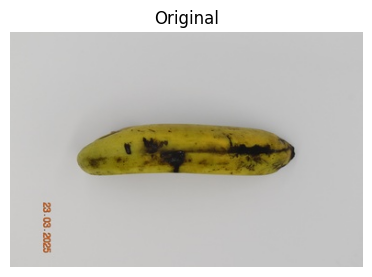

In [107]:
show(Xv_train[0])

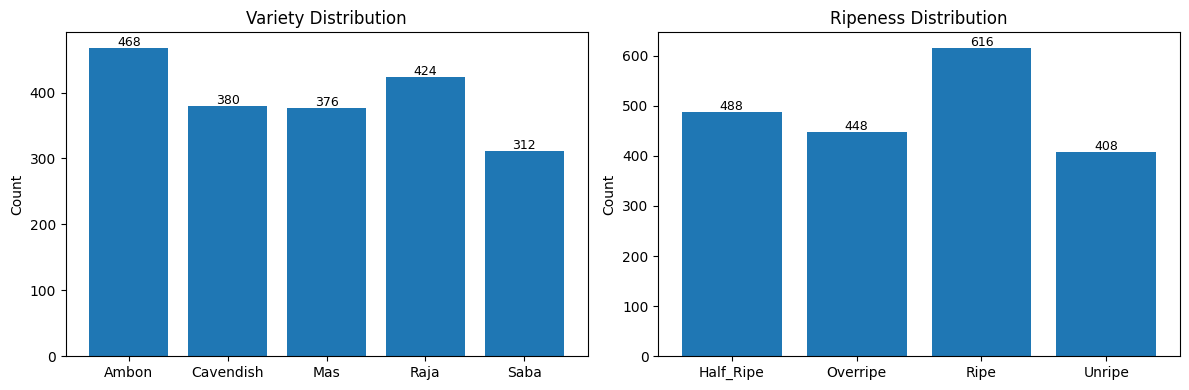

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, class_names, title in [
  (axes[0], variety_labels,  variety_class_names,  "Variety Distribution"),
  (axes[1], ripeness_labels, ripeness_class_names, "Ripeness Distribution"),
]:
  counts = [list(labels).count(i) for i in range(len(class_names))]
  ax.bar(class_names, counts)
  ax.set_title(title)
  ax.set_ylabel("Count")
  for i, c in enumerate(counts):
    ax.text(i, c + 3, str(c), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "class_distribution.png"), dpi=150)
plt.show()

## 2. Image Enhancement

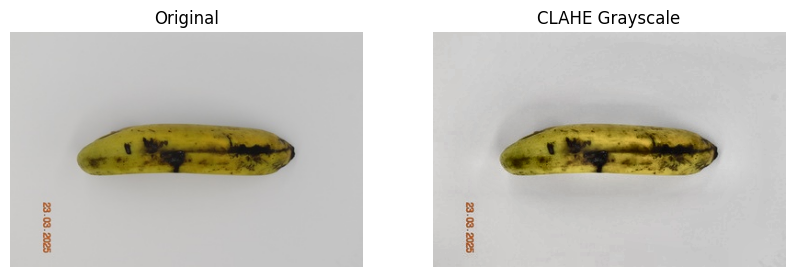

In [109]:
def image_enhancement(img):
  # 1. Convert to LAB
  img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

  # 2. Split channels
  L, A, B = cv2.split(img_lab)

  # 3. Apply CLAHE to L channel for the grayscale image
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
  L_enhanced = clahe.apply(L)

  # 4. Merge back
  lab_enhanced = cv2.merge([L_enhanced, A, B])

  # 5. Convert back to RGB (for visualization / further processing)
  enhanced_img = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)

  return enhanced_img

img_enhanced = image_enhancement(Xv_train[0])
show(Xv_train[0], img_enhanced, title2="CLAHE Grayscale")

## 3. Image Segmentation

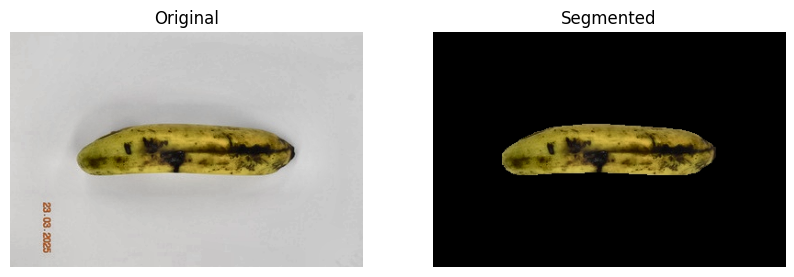

In [110]:
def segment_banana(img):
  hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
  S = hsv[:, :, 1]  # saturation channel
  _, mask = cv2.threshold(S, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
  mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8), iterations=3)
  mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((5,5), np.uint8), iterations=2)

  img_masked = cv2.bitwise_and(img, img, mask=mask)
  return img_masked, mask

# Apply and visualise
img_masked, _ = segment_banana(img_enhanced)
show(img_enhanced, img_masked, title2="Segmented")

## 4. Feature Extraction

In [111]:
def process_image(img): # Helper function to apply the previous steps
  img_enhanced = image_enhancement(img)
  img_masked, mask = segment_banana(img_enhanced)
  return img_masked, mask

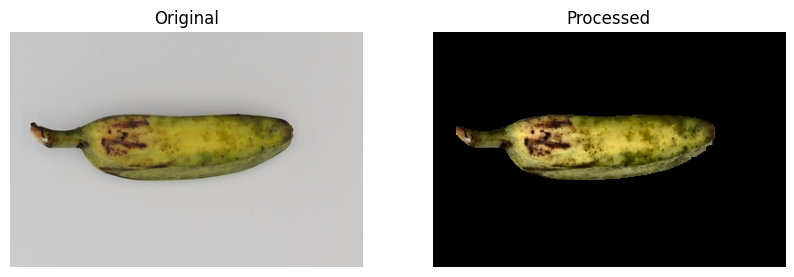

In [112]:
banana = Xv_train[400]
processed_banana_image, _ = process_image(banana) # Unpack the returned tuple
show(banana, processed_banana_image) # Pass only the image part for display

In [113]:
def extract_ripeness_features(img):
  segmented, mask = process_image(img)
  hsv = cv2.cvtColor(segmented, cv2.COLOR_RGB2HSV)

  # 1. HSV histograms (32 bins per channel)
  hist_feat = []
  for ch in range(3):
    hist = cv2.calcHist([hsv], [ch], mask, [32], [0, 256]).flatten()
    hist_feat.extend(hist / (hist.sum() + 1e-6))

  # 2. Color Moments (mean, variance, skewness per channel)
  moment_feat = []
  for ch in range(3):
    px = hsv[:,:,ch][mask > 0].astype(np.float32)
    mean = px.mean()
    var  = px.var()
    skew = float(np.mean(((px - mean) / (px.std() + 1e-6)) ** 3))
    moment_feat.extend([mean, var, skew])

  # 3. LBP histogram
  gray     = cv2.cvtColor(segmented, cv2.COLOR_RGB2GRAY)
  lbp      = local_binary_pattern(gray, P=8, R=1, method="uniform")
  lbp_hist, _ = np.histogram(lbp[mask > 0], bins=10, range=(0, 10), density=True)

  return np.array(hist_feat + moment_feat + lbp_hist.tolist(), dtype=np.float32)

extract_ripeness_features(Xr_train[0])

array([ 2.49320036e-03,  8.72620102e-03,  2.95217596e-02,  4.09848154e-01,
        5.43007731e-01,  5.89301903e-03,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  5.66636445e-05,
        0.00000000e+00,  2.83318223e-04,  1.69990934e-04,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        5.66636445e-05,  0.00000000e+00,  0.00000000e+00,  2.83318223e-04,
        1.69990934e-04,  2.26654578e-04,  2.26654578e-04,  1.13327289e-04,
        3.96645512e-04,  2.83318223e-04,  1.69990934e-04,  3.39981867e-04,
        4.02311888e-03,  4.70308261e-03,  7.42293755e-03,  1.11627383e-02,
        1.90956481e-02,  7.40593821e-02,  9.43449661e-02,  7.24161342e-02,
        6.51065260e-02,  

In [114]:
def extract_variety_features(img):
  segmented, mask = process_image(img)
  gray = cv2.cvtColor(segmented, cv2.COLOR_RGB2GRAY)

  # 1. LBP histogram
  lbp      = local_binary_pattern(gray, P=8, R=1, method="uniform")
  lbp_hist, _ = np.histogram(lbp[mask > 0], bins=10, range=(0, 10), density=True)

  # 2. GLCM Haralick (4 angles)
  glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                      levels=256, symmetric=True, normed=True)
  glcm_feat = np.concatenate([graycoprops(glcm, prop).flatten()
                              for prop in ['contrast', 'dissimilarity',
                                           'homogeneity', 'energy', 'correlation']])

  # 3. HOG
  gray_resized = cv2.resize(gray, (128, 128))
  hog_feat = hog(gray_resized, orientations=8, pixels_per_cell=(16,16),
                 cells_per_block=(2,2), feature_vector=True)

  # 4. Hu Moments (log-transformed)
  moments = cv2.moments(mask)
  hu = cv2.HuMoments(moments).flatten()
  hu_feat = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

  # 5. Zernike Moments (order 8)
  mask_resized = cv2.resize(mask, (128, 128))
  zernike_feat = zernike_moments(mask_resized, radius=64, degree=8)

  # 6. Contour descriptors
  contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if contours:
    cnt      = max(contours, key=cv2.contourArea)
    area     = cv2.contourArea(cnt)
    x,y,w,h  = cv2.boundingRect(cnt)
    aspect   = w / (h + 1e-6)
    extent   = area / (w * h + 1e-6)
    hull     = cv2.convexHull(cnt)
    solidity = area / (cv2.contourArea(hull) + 1e-6)

    img_area = segmented.shape[0] * segmented.shape[1]
    norm_area = area / (img_area + 1e-6)
    contour_feat = [norm_area, aspect, extent, solidity]
  else:
    contour_feat = [0, 0, 0, 0]

  return np.concatenate([lbp_hist.tolist(), glcm_feat, hog_feat, hu_feat, zernike_feat,
                         np.array(contour_feat)]).astype(np.float32)

extract_variety_features(Xv_train[0])

array([0.06265526, 0.07617996, 0.06624345, ..., 4.160714  , 0.8140328 ,
       0.96831983], dtype=float32)

In [115]:
# For variety classification
Xv_train_features = np.array([extract_variety_features(img) for img in tqdm(Xv_train, desc="Variety Train...")])
Xv_val_features   = np.array([extract_variety_features(img) for img in tqdm(Xv_val,   desc="Variety Val...")])
Xv_test_features  = np.array([extract_variety_features(img) for img in tqdm(Xv_test,  desc="Variety Test...")])

# For ripeness classification
Xr_train_features = np.array([extract_ripeness_features(img) for img in tqdm(Xr_train, desc="Ripeness Train...")])
Xr_val_features   = np.array([extract_ripeness_features(img) for img in tqdm(Xr_val,   desc="Ripeness Val...")])
Xr_test_features  = np.array([extract_ripeness_features(img) for img in tqdm(Xr_test,  desc="Ripeness Test...")])

print(f"Variety Train feature matrix: {Xv_train_features.shape}")
print(f"Variety Val feature matrix:   {Xv_val_features.shape}")
print(f"Variety Test feature matrix:  {Xv_test_features.shape}")

Ripeness Test...: 100%|██████████| 294/294 [00:12<00:00, 24.30it/s]

Variety Train feature matrix: (1372, 1634)
Variety Val feature matrix:   (294, 1634)
Variety Test feature matrix:  (294, 1634)


## 5. Scaling and PCA

In [116]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def fit_scaler_pca(X_train, X_val, X_test, tag):
  scaler = StandardScaler()
  X_train_s = scaler.fit_transform(X_train)
  X_val_s   = scaler.transform(X_val)
  X_test_s  = scaler.transform(X_test)

  pca = PCA(n_components=0.95, svd_solver='full', random_state=RANDOM_SEED)
  X_train_p = pca.fit_transform(X_train_s)
  X_val_p   = pca.transform(X_val_s)
  X_test_p  = pca.transform(X_test_s)

  joblib.dump(scaler, os.path.join(MODELS_DIR, f"scaler_{tag}.pkl"))
  joblib.dump(pca,    os.path.join(MODELS_DIR, f"pca_{tag}.pkl"))

  print(f"[{tag}] PCA components retained: {pca.n_components_} "
        f"(from {X_train.shape[1]} dims)")
  return X_train_p, X_val_p, X_test_p

Pv_train, Pv_val, Pv_test = fit_scaler_pca(Xv_train_features, Xv_val_features, Xv_test_features, "variety")
Pr_train, Pr_val, Pr_test = fit_scaler_pca(Xr_train_features, Xr_val_features, Xr_test_features, "ripeness")

[variety] PCA components retained: 263 (from 1634 dims)
[ripeness] PCA components retained: 37 (from 115 dims)


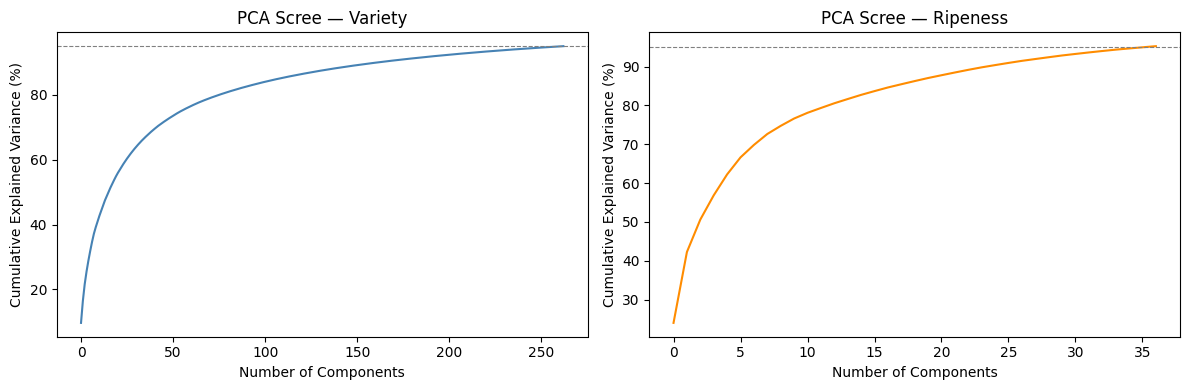

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, tag, color in [(axes[0], "variety", "steelblue"), (axes[1], "ripeness", "darkorange")]:
  pca = joblib.load(os.path.join(MODELS_DIR, f"pca_{tag}.pkl"))
  cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
  ax.plot(cumvar, color=color)
  ax.axhline(95, linestyle='--', color='gray', linewidth=0.8)
  ax.set_xlabel("Number of Components")
  ax.set_ylabel("Cumulative Explained Variance (%)")
  ax.set_title(f"PCA Scree — {tag.capitalize()}")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pca_scree.png"), dpi=150)
plt.show()

# 6. Model Training (SVM + Grid Search)

In [118]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
  'C':      [0.1, 1, 10, 100],
  'gamma':  ['scale', 'auto', 0.001, 0.01],
  'kernel': ['rbf', 'poly'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def train_svm(X_train, y_train, tag):
  grid = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=RANDOM_SEED),
    param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1
  )
  grid.fit(X_train, y_train)
  print(f"[{tag}] Best params: {grid.best_params_}")
  print(f"[{tag}] Best CV F1 (macro): {grid.best_score_:.4f}")
  joblib.dump(grid.best_estimator_, os.path.join(MODELS_DIR, f"svm_{tag}.pkl"))
  return grid.best_estimator_

svm_variety  = train_svm(Pv_train, yv_train, "variety")
svm_ripeness = train_svm(Pr_train, yr_train, "ripeness")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[variety] Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
[variety] Best CV F1 (macro): 0.7718
Fitting 5 folds for each of 32 candidates, totalling 160 fits
[ripeness] Best params: {'C': 1, 'gamma': 'auto', 'kernel': 'poly'}
[ripeness] Best CV F1 (macro): 0.7960


In [119]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest, For Baseline
def train_rf(X_train, y_train, tag):
  rf = RandomForestClassifier(
      n_estimators=200, class_weight='balanced',
      random_state=RANDOM_SEED, n_jobs=-1
  )
  rf.fit(X_train, y_train)
  joblib.dump(rf, os.path.join(MODELS_DIR, f"rf_{tag}.pkl"))
  return rf

rf_variety  = train_rf(Pv_train, yv_train, "variety")
rf_ripeness = train_rf(Pr_train, yr_train, "ripeness")

# 7. Evaluation

In [120]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate(model, X_test, y_test, class_names, tag, model_name):
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  print(f"\n{'='*50}")
  print(f"{model_name} — {tag.upper()}")
  print(f"Accuracy: {acc:.4f}")
  print(classification_report(y_test, y_pred, target_names=class_names))

  # Save report
  report = classification_report(y_test, y_pred, target_names=class_names)
  with open(os.path.join(RESULTS_DIR, f"report_{tag}_{model_name}.txt"), "w") as f:
    f.write(f"Accuracy: {acc:.4f}\n\n{report}")

  # Confusion matrix
  cm = confusion_matrix(y_test, y_pred, normalize='true')
  fig, ax = plt.subplots(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=class_names,
              yticklabels=class_names, cmap='Blues', ax=ax)
  ax.set_xlabel("Predicted")
  ax.set_ylabel("True")
  ax.set_title(f"Confusion Matrix — {model_name} {tag.capitalize()}")
  plt.tight_layout()
  plt.savefig(os.path.join(RESULTS_DIR, f"cm_{tag}_{model_name}.png"), dpi=150)
  plt.show()

  return y_pred


SVM — VARIETY
Accuracy: 0.8163
              precision    recall  f1-score   support

       Ambon       0.83      0.90      0.86        70
   Cavendish       0.79      0.79      0.79        57
         Mas       0.98      0.96      0.97        57
        Raja       0.73      0.76      0.74        63
        Saba       0.74      0.62      0.67        47

    accuracy                           0.82       294
   macro avg       0.81      0.81      0.81       294
weighted avg       0.82      0.82      0.81       294



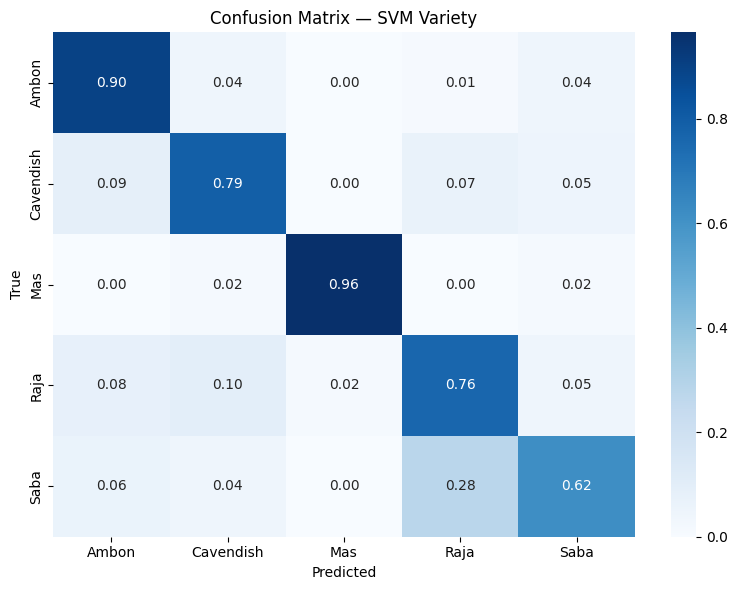


SVM — RIPENESS
Accuracy: 0.8095
              precision    recall  f1-score   support

   Half_Ripe       0.74      0.78      0.76        74
    Overripe       0.81      0.82      0.81        67
        Ripe       0.87      0.83      0.85        92
      Unripe       0.80      0.80      0.80        61

    accuracy                           0.81       294
   macro avg       0.81      0.81      0.81       294
weighted avg       0.81      0.81      0.81       294



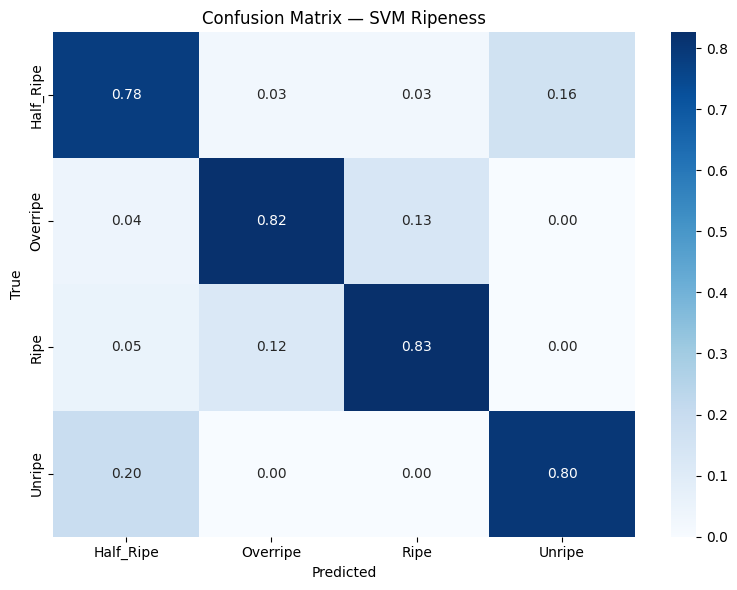


RF — VARIETY
Accuracy: 0.7279
              precision    recall  f1-score   support

       Ambon       0.72      0.89      0.79        70
   Cavendish       0.76      0.61      0.68        57
         Mas       0.89      0.98      0.93        57
        Raja       0.56      0.68      0.61        63
        Saba       0.82      0.38      0.52        47

    accuracy                           0.73       294
   macro avg       0.75      0.71      0.71       294
weighted avg       0.74      0.73      0.72       294



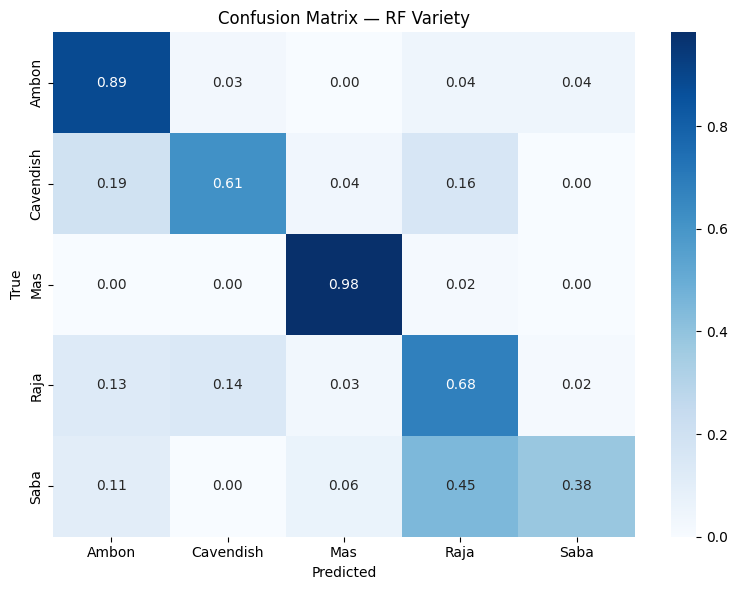


RF — RIPENESS
Accuracy: 0.7449
              precision    recall  f1-score   support

   Half_Ripe       0.73      0.64      0.68        74
    Overripe       0.75      0.70      0.72        67
        Ripe       0.72      0.78      0.75        92
      Unripe       0.79      0.87      0.83        61

    accuracy                           0.74       294
   macro avg       0.75      0.75      0.75       294
weighted avg       0.74      0.74      0.74       294



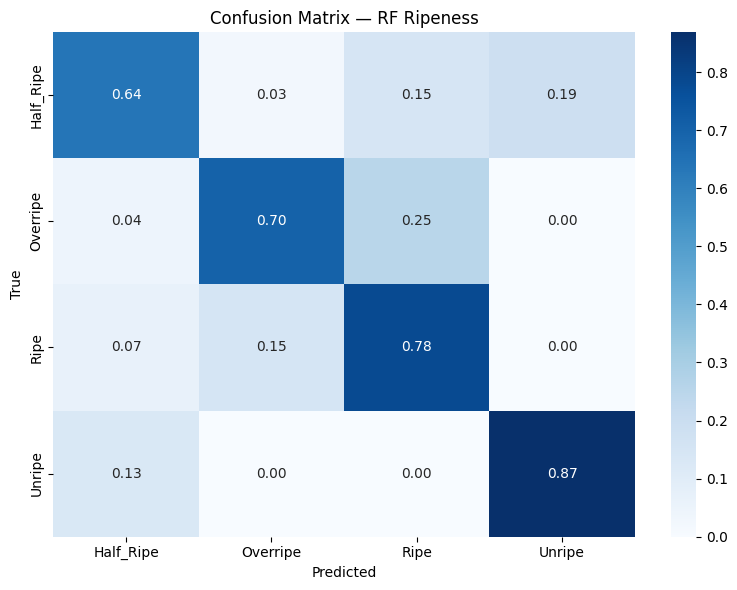

array([3, 1, 2, 2, 0, 3, 2, 0, 3, 3, 1, 2, 0, 0, 1, 3, 3, 1, 2, 2, 2, 2,
       2, 2, 0, 2, 1, 1, 0, 3, 2, 3, 1, 2, 3, 1, 0, 1, 2, 2, 0, 0, 2, 1,
       2, 2, 1, 2, 1, 2, 2, 3, 3, 2, 0, 1, 0, 1, 2, 1, 0, 2, 0, 2, 2, 2,
       1, 0, 1, 1, 2, 2, 3, 3, 2, 3, 3, 2, 2, 1, 0, 3, 3, 1, 0, 2, 1, 3,
       2, 3, 0, 2, 3, 1, 1, 2, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3, 3, 2, 3, 2,
       3, 2, 3, 2, 0, 2, 2, 0, 3, 2, 2, 3, 1, 3, 3, 1, 0, 3, 2, 2, 0, 1,
       3, 2, 1, 3, 2, 0, 2, 0, 0, 1, 3, 0, 2, 3, 1, 0, 1, 1, 1, 2, 2, 1,
       0, 0, 3, 2, 3, 2, 2, 0, 2, 2, 3, 2, 0, 1, 2, 2, 3, 1, 2, 1, 0, 0,
       0, 2, 0, 2, 3, 1, 1, 1, 3, 0, 2, 3, 2, 1, 0, 0, 1, 2, 0, 0, 3, 2,
       2, 3, 1, 1, 1, 2, 3, 2, 2, 2, 1, 1, 0, 2, 3, 1, 1, 2, 1, 0, 0, 0,
       0, 0, 3, 1, 2, 0, 0, 0, 1, 1, 0, 2, 1, 3, 2, 2, 1, 1, 0, 1, 0, 3,
       0, 2, 2, 1, 1, 2, 2, 3, 0, 1, 1, 2, 0, 3, 2, 3, 2, 0, 1, 3, 3, 0,
       3, 2, 3, 2, 0, 2, 3, 0, 3, 0, 0, 2, 3, 1, 2, 2, 3, 0, 2, 0, 0, 2,
       2, 2, 3, 3, 0, 1, 3, 2])

In [121]:
evaluate(svm_variety,  Pv_test, yv_test, variety_class_names,  "variety",  "SVM")
evaluate(svm_ripeness, Pr_test, yr_test, ripeness_class_names, "ripeness", "SVM")
evaluate(rf_variety,   Pv_test, yv_test, variety_class_names,  "variety",  "RF")
evaluate(rf_ripeness,  Pr_test, yr_test, ripeness_class_names, "ripeness", "RF")

In [123]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score


def ablation_run(F_train, F_val, y_train, y_val, feature_mask, tag):
  X_tr = F_train[:, feature_mask]
  X_vl = F_val[:, feature_mask]
  sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_vl = sc.transform(X_vl)
  pca = PCA(n_components=min(0.95, X_tr.shape[1]-1), svd_solver='full', random_state=RANDOM_SEED)
  X_tr = pca.fit_transform(X_tr); X_vl = pca.transform(X_vl)
  svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=RANDOM_SEED)
  svm.fit(X_tr, y_train)
  f1 = f1_score(y_val, svm.predict(X_vl), average='macro')
  return round(f1, 4)

# Rename for clarity as per the original function signatures
Fv_train, Fv_val, Fv_test = Xv_train_features, Xv_val_features, Xv_test_features
Fr_train, Fr_val, Fr_test = Xr_train_features, Xr_val_features, Xr_test_features

# --- Define feature indices for VARIETY --- (578  total features)
# Concatenation order in extract_variety_features: [lbp_hist, glcm_feat, hog_feat, hu_feat, zernike_feat, contour_feat]
# LBP: 10, GLCM: 20, HOG: 1568, Hu: 7, Zernike: 25, Contour: 4

variety_lbp_idx     = list(range(0, 10))
variety_glcm_idx    = list(range(10, 30))
variety_hog_idx     = list(range(30, 542))
variety_hu_idx      = list(range(542, 549))
variety_zernike_idx = list(range(549, 574))
variety_contour_idx = list(range(574, 578))

variety_color_mask   = [] # No explicit color features for variety (uses grayscale early)
variety_texture_mask = variety_lbp_idx + variety_glcm_idx # LBP and GLCM
variety_shape_mask   = variety_hog_idx + variety_hu_idx + variety_zernike_idx + variety_contour_idx # HOG, Hu, Zernike, Contour

# --- Define feature indices for RIPENESS --- (115 total features)
# Concatenation order in extract_ripeness_features: [HSV histograms, Color Moments, LBP histogram]
# HSV histograms: 96, Color Moments: 9, LBP histogram: 10

ripeness_hsv_hist_idx      = list(range(0, 96))
ripeness_color_moments_idx = list(range(96, 105))
ripeness_lbp_idx           = list(range(105, 115))

ripeness_color_mask   = ripeness_hsv_hist_idx + ripeness_color_moments_idx # HSV Hist and Color Moments
ripeness_texture_mask = ripeness_lbp_idx # LBP
ripeness_shape_mask   = [] # No explicit shape features for ripeness

# --- General configurations mapping to specific masks ---
# These conceptual categories will be used for both tasks, but map to different feature sets
ablation_configs = {
    "Full Features": {
        "variety":  list(range(Fv_train.shape[1])),
        "ripeness": list(range(Fr_train.shape[1]))
    },
    "Color Only": {
        "variety":  variety_color_mask,
        "ripeness": ripeness_color_mask
    },
    "Texture Only": {
        "variety":  variety_texture_mask,
        "ripeness": ripeness_texture_mask
    },
    "Shape Only": {
        "variety":  variety_shape_mask,
        "ripeness": ripeness_shape_mask
    },
    "No Color": {
        "variety":  variety_texture_mask + variety_shape_mask,
        "ripeness": ripeness_texture_mask + ripeness_shape_mask
    },
    "No Texture": {
        "variety":  variety_color_mask + variety_shape_mask,
        "ripeness": ripeness_color_mask + ripeness_shape_mask
    },
    "No Shape": {
        "variety":  variety_color_mask + variety_texture_mask,
        "ripeness": ripeness_color_mask + ripeness_texture_mask
    }
}

print(f"{'Config':<20} {'Variety F1':>12} {'Ripeness F1':>12}")
print("-" * 46)

ablation_results = {}
for name, masks in ablation_configs.items():
  f1_v_display = "N/A"
  f1_r_display = "N/A"
  f1_v = 0.0
  f1_r = 0.0

  if masks["variety"] and len(masks["variety"]) > 0:
    f1_v = ablation_run(Fv_train, Fv_val, yv_train, yv_val, masks["variety"], "variety")
    f1_v_display = f"{f1_v:.4f}"

  if masks["ripeness"] and len(masks["ripeness"]) > 0:
    f1_r = ablation_run(Fr_train, Fr_val, yr_train, yr_val, masks["ripeness"], "ripeness")
    f1_r_display = f"{f1_r:.4f}"

  ablation_results[name] = (f1_v, f1_r)
  print(f"{name:<20} {f1_v_display:>12} {f1_r_display:>12}")

Config                 Variety F1  Ripeness F1
----------------------------------------------
Full Features              0.8118       0.8038
Color Only                    N/A       0.7825
Texture Only               0.7500       0.5723
Shape Only                 0.5353          N/A
No Color                   0.7227       0.5723
No Texture                 0.5353       0.7825
No Shape                   0.7500       0.8038
